In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import gamma
from reliability.Fitters import Fit_Weibull_2P


previous_result

In [217]:
df = pd.read_csv("reliability_dataset1.csv")


def fit_groups(df):

    results = []

    groups = df.groupby(
        [
            "Test_Type",
            "Stress_Temperature_C",
            "Stress_Voltage_V",
            "Humidity_Percent",
        ]
    )

    for (test_name, temp, voltage, humidity), group_data in groups:

        failures = group_data.loc[
            group_data["Censored"] == 0,
            "Failure_Time_Hours",
        ].values

        censored = group_data.loc[
            group_data["Censored"] == 1,
            "Failure_Time_Hours",
        ].values

        if len(failures) < 5:
            continue

        weibull_fit = Fit_Weibull_2P(
            failures=failures,
            right_censored=censored,
            show_probability_plot=False,
            print_results=False,
        )

        result_table = weibull_fit.results

        eta = float(
            result_table.loc[
                result_table["Parameter"] == "Alpha",
                "Point Estimate",
            ].values[0]
        )

        beta = float(
            result_table.loc[
                result_table["Parameter"] == "Beta",
                "Point Estimate",
            ].values[0]
        )

        mttf = eta * gamma(1 + 1 / beta)

        if beta < 0.9:
            hazard = "Decreasing"
        elif beta <= 1.1:
            hazard = "Constant"
        else:
            hazard = "Increasing"

        results.append(
            {
                "Test_Type": test_name,
                "Temp_C": temp,
                "Volt_V": voltage,
                "Humidity_%": humidity,
                "Total_Devices": len(group_data),
                "Failed_Devices": len(failures),
                "Censored_Devices": len(censored),
                "Beta": beta,
                "Eta": eta,
                "MTTF": mttf,
                "Hazard": hazard,
            }
        )

    return pd.DataFrame(results)


result = fit_groups(df)
print(result)

   Test_Type  Temp_C  Volt_V  Humidity_%  ...    Beta     Eta    MTTF      Hazard
0       HTOL     100       4          40  ... 2.11599 1962.53 1738.13  Increasing
1       HTOL     100     4.5          40  ... 2.21341 1809.93 1602.96  Increasing
2       HTOL     100       5          40  ... 2.18951 1725.35    1528  Increasing
3       HTOL     125       4          40  ... 2.04061 800.545  709.24  Increasing
4       HTOL     125     4.5          40  ... 2.11489 762.254 675.095  Increasing
5       HTOL     125       5          40  ... 2.16711 718.624 636.416  Increasing
6       HTOL     150       4          40  ... 2.15721 371.923 329.377  Increasing
7       HTOL     150     4.5          40  ... 2.13481 341.269 302.236  Increasing
8       HTOL     150       5          40  ... 2.10669 323.045 286.113  Increasing
9         TC     -40       0          40  ... 1.74571 882.655  786.22  Increasing
10        TC     125       0          40  ... 1.78572 903.189 803.512  Increasing
11       THB    

Phase 3A

Build Arrhenius Lifetime Model

In [230]:
def build_arrhenius_model(result):

    htol_data = (
        result[
            result["Test_Type"] == "HTOL"
        ]
        .copy()
    )

    htol_data["Temp_K"] = (
        htol_data["Temp_C"]
        + 273.15
    )

    inverse_temperature = (
        1
        /
        htol_data["Temp_K"]
    )

    log_eta = np.log(
        htol_data["Eta"]
    )

    slope, intercept = np.polyfit(
        inverse_temperature,
        log_eta,
        1
    )

    return slope, intercept

In [264]:
def plot_arrhenius_model(result):

    htol_data = (
        result[
            result["Test_Type"] == "HTOL"
        ]
        .copy()
    )

    htol_data["Temp_K"] = (
        htol_data["Temp_C"]
        + 273.15
    )

    inverse_temperature = (
        1
        /
        htol_data["Temp_K"]
    )

    log_eta = np.log(
        htol_data["Eta"]
    )

    slope, intercept = np.polyfit(
        inverse_temperature,
        log_eta,
        1
    )

    x_fit = np.linspace(
        inverse_temperature.min(),
        inverse_temperature.max(),
        100
    )

    y_fit = (
        slope
        *
        x_fit
        +
        intercept
    )

    plt.figure(
        figsize=(10,6)
    )

    plt.scatter(
        inverse_temperature,
        log_eta,
        s=120,
        label="HTOL Data"
    )

    plt.plot(
        x_fit,
        y_fit,
        linewidth=3,
        label="Arrhenius Fit"
    )

    for _, row in htol_data.iterrows():

        plt.annotate(
            f"{row['Temp_C']}°C",
            (
                1 / row["Temp_K"],
                np.log(row["Eta"])
            ),
            xytext=(8,8),
            textcoords="offset points"
        )

    plt.title(
        "Arrhenius Model Construction"
    )

    plt.xlabel(
        "1 / Temperature (1/K)"
    )

    plt.ylabel(
        "ln(Eta)"
    )

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

    plt.show()

    print("\n")
    print("=" * 60)
    print(
        f"Slope     : {slope:.4f}"
    )
    print(
        f"Intercept : {intercept:.4f}"
    )
    print("=" * 60)

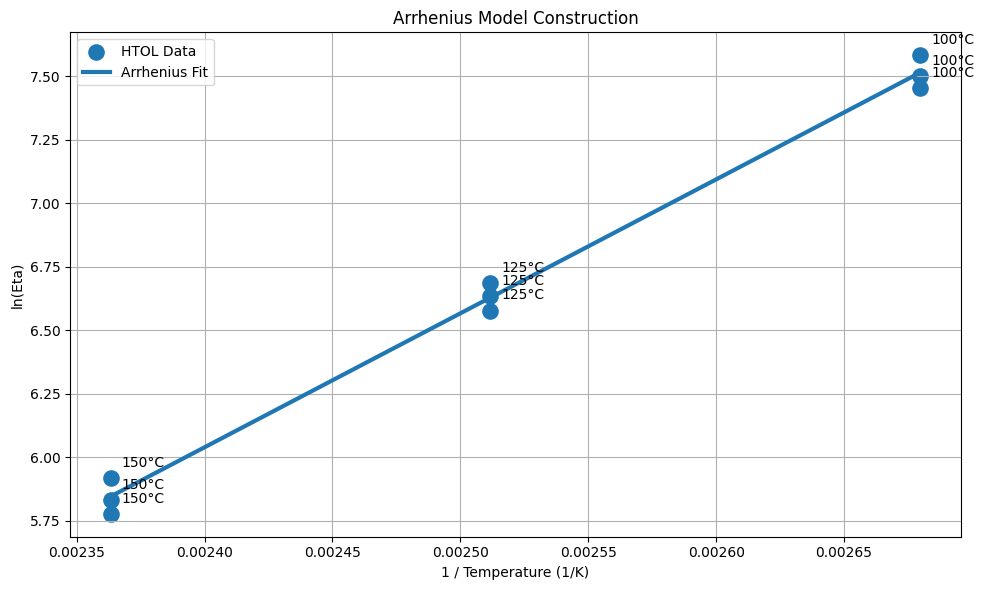



Slope     : 5269.6952
Intercept : -6.6077


In [265]:
slope, intercept = plot_arrhenius_fit(result)

##Phase 3B

Predict Eta

In [277]:
def predict_eta(
    temperature_c,
    slope,
    intercept
):

    temperature_k = (
        temperature_c
        + 273.15
    )

    inverse_temperature = (
        1
        /
        temperature_k
    )

    predicted_log_eta = (
        slope
        *
        inverse_temperature
        +
        intercept
    )

    predicted_eta = np.exp(
        predicted_log_eta
    )

    return predicted_eta

In [278]:
slope, intercept = (
    build_arrhenius_model(
        result
    )
)

eta = predict_eta(
    temperature_c=110,
    slope=slope,
    intercept=intercept
)

print(eta)

1268.929328158591


Phase 3C

Predict MTTF

In [305]:
def predict_mttf(
    eta,
    beta
):

   return (
        eta
        *
        gamma(
            1 + 1/beta
        )
    )

In [306]:
mttf = predict_mttf(eta, beta=2.2)  ## eta was already defined in the previous section
print(mttf)

1123.795232278694


In [315]:
mttf = predict_mttf(2100, 2.5)
print(mttf)

1863.254016756458


Phase 3D

Reliability Function

In [316]:
def reliability_function(
    time_hours,
    eta,
    beta
):

    return np.exp(
        -(
            time_hours
            /
            eta
        )
        **
        beta
    )

In [364]:
#example
# the probability that a device will survive after 500 h is given by: 

probability_500_percent = reliability_function(500,eta, beta) * 100 
print(
    f"{probability_500_percent:.2f}%"
)

87.91%


Phase 3E

Failure Probability

In [365]:
def failure_probability(
    time_hours,
    eta,
    beta
):

    return (
        1
        -
        reliability_function(
            time_hours,
            eta,
            beta
        )
    )

In [366]:
#example
# the probability that a device will be failed after 500 h is given by: 
failure_500 = failure_probability(500, eta, beta) * 100
print(f"{failure_500: .2f}%")

 12.09%


Phase 3F

Mission Profile Analysis

In [367]:
def mission_profile_analysis(
    mission_time,
    eta,
    beta
):

    reliability = (
        reliability_function(
            mission_time,
            eta,
            beta
        )
    )

    failure = (
        failure_probability(
            mission_time,
            eta,
            beta
        )
    )

    print("\nMISSION PROFILE")

    print(
        f"Mission Time : {mission_time:.0f} h"
    )

    print(
        f"Reliability  : {reliability:.4f}"
    )

    print(
        f"Failure Prob : {failure:.4f}"
    )

Phase 3G

Reliability Risk Classification

In [368]:
def classify_risk(
    reliability
):

    if reliability >= 0.95:
        return "LOW RISK"

    elif reliability >= 0.85:
        return "MEDIUM RISK"

    else:
        return "HIGH RISK"

In [374]:
#Example
probability_500 = reliability_function(500,eta, beta)  
classify_risk(probability_500)

'MEDIUM RISK'

Phase 3H

Field Life Projection

In [370]:
def field_life_projection(
    accelerated_life,
    field_temperature_c,
    activation_energy=0.45
):

    k_b = (
        8.617333262145e-5
    )

    stress_temperature = (
        150
        + 273.15
    )

    field_temperature = (
        field_temperature_c
        + 273.15
    )

    acceleration_factor = np.exp(
        (
            activation_energy
            /
            k_b
        )
        *
        (
            (
                1
                /
                field_temperature
            )
            -
            (
                1
                /
                stress_temperature
            )
        )
    )

    return (
        accelerated_life
        *
        acceleration_factor
    )



Accelerated testing is performed at elevated stress temperatures to obtain failures within a practical 
test duration. The Arrhenius acceleration model is then used to translate the observed accelerated
lifetime into an equivalent field lifetime under normal operating conditions.

In [371]:
field_temp = field_life_projection( accelerated_life = 1000,
    field_temperature_c = 55,
    activation_energy=0.45)
print(f"{field_temp: .0f}")

 35613


Phase 3 Final Example

In [372]:
slope, intercept = (
    build_arrhenius_model(
        result
    )
)

beta = 2.2

eta = predict_eta(
    temperature_c=110,
    slope=slope,
    intercept=intercept
)

mttf = predict_mttf(
    eta,
    beta
)

reliability = (
    reliability_function(
        1000,
        eta,
        beta
    )
)

failure = (
    failure_probability(
        1000,
        eta,
        beta
    )
)

print(
    "\nRELIABILITY PREDICTION"
)

print(
    f"Predicted Eta  : {eta:.1f}"
)

print(
    f"Predicted MTTF : {mttf:.1f}"
)

print(
    f"Reliability    : {reliability:.4f}"
)

print(
    f"Failure Prob   : {failure:.4f}"
)

print(
    classify_risk(
        reliability
    )
)


RELIABILITY PREDICTION
Predicted Eta  : 1268.9
Predicted MTTF : 1123.8
Reliability    : 0.5531
Failure Prob   : 0.4469
HIGH RISK
